<a href="https://colab.research.google.com/github/JozefSL/pyNotes/blob/main/sc/2Sv1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### S-Curve Model for Monthly New Well Count

To model the gradual increase in new well count from an initial 500 wells/month to a stabilized 650 wells/month, while achieving a total of 7000 wells over the next 12 months, I will use an S-curve based on the error function (`erf`).

The `erf` function is ideal for this as it provides a smooth, sigmoidal transition from a lower bound to an upper bound. The general form of the S-curve for the monthly rate will be:

`N(t) = InitialRate + (StabilizedRate - InitialRate) * 0.5 * (1 + erf((t - t_mid) / (sigma * sqrt(2))))`

Where:
- `N(t)`: Monthly new well count at month `t`.
- `InitialRate`: The starting monthly well count (500).
- `StabilizedRate`: The eventual monthly well count (650).
- `t_mid`: The midpoint of the S-curve, where the growth is steepest.
- `sigma`: Controls the spread or steepness of the S-curve. A smaller `sigma` means a steeper curve.

I will use numerical optimization to find the values of `t_mid` and `sigma` that satisfy the condition of 7000 total wells over 12 months. The initial conditions (500 wells/month at `t=0`) and stabilization (650 wells/month) are inherently handled by the model's structure.

In [24]:
import numpy as np
from scipy.special import erf
from scipy.optimize import least_squares
import matplotlib.pyplot as plt

# Define the S-curve function for the monthly rate
def s_curve_rate(t, t_mid, sigma, initial_rate=500, final_rate=650):
    """
    S-curve model for monthly new well count rate using the error function.
    Ranges from initial_rate to final_rate.
    """
    if sigma <= 0: # Ensure sigma is positive for a valid curve
        return np.full_like(t, 1e9) # Return a large penalty value

    # The erf function ranges from -1 to 1.
    # 0.5 * (1 + erf(x)) will range from 0 to 1.
    growth_factor = 0.5 * (1 + erf((t - t_mid) / (sigma * np.sqrt(2))))
    return initial_rate + (final_rate - initial_rate) * growth_factor

Optimizing S-curve parameters...
Optimization successful!
Optimized t_mid: 4.83 months, Optimized sigma: 1.88

--- Verification ---
Initial month's rate (Month 0): 500.77 wells/month (Target: 500)
Total wells for first 12 months: 7000.00 wells (Target: 7000)
Stabilized rate (Month 23): 650.00 wells/month (Target: ~650)


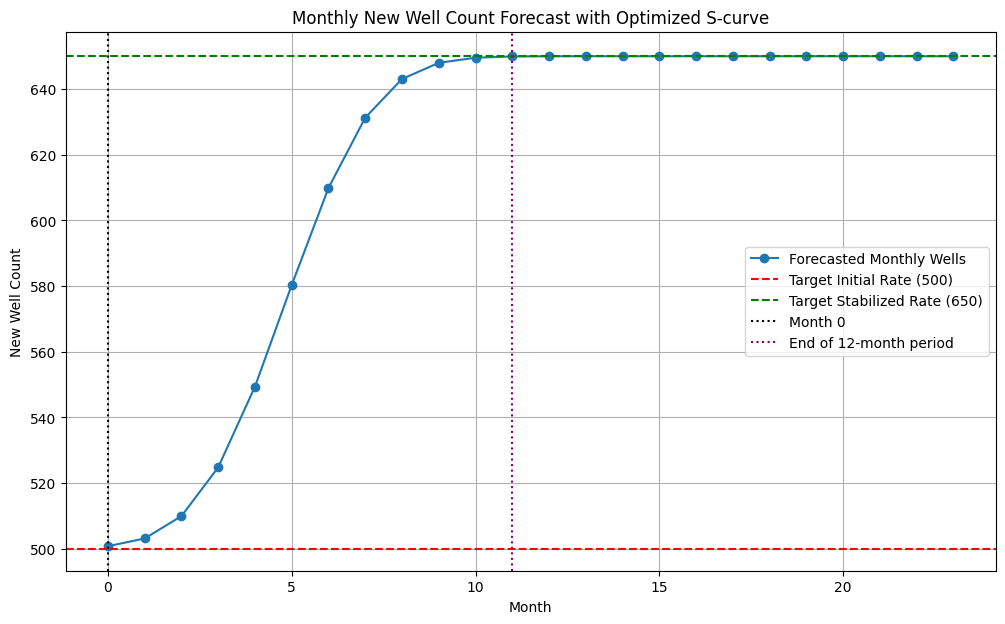

In [25]:
# Define the objective function for optimization
def objective_function(params, target_sum=7000, num_months=12):
    """
    Calculates the difference between the actual sum of wells over num_months
    and the target_sum. This function is minimized by least_squares.
    """
    t_mid, sigma = params

    # Generate time points for the 12 months (0 to 11)
    months = np.arange(num_months)

    # Calculate monthly well counts using the S-curve model
    monthly_counts = s_curve_rate(months, t_mid, sigma)

    # Sum the monthly counts
    current_sum = np.sum(monthly_counts)

    # Return the residual (difference from target_sum)
    return [current_sum - target_sum]

# Initial guess for the parameters (t_mid, sigma)
# t_mid: The midpoint of the S-curve (e.g., around month 6)
# sigma: Controls the steepness (e.g., 3 months for a reasonable spread)
initial_guess = [6, 3]

# Bounds for the parameters:
# t_mid: Can be negative (if growth starts before month 0) or positive.
# sigma: Must be positive.
bounds = ([-10, 0.1], [20, 10]) # t_mid: -10 to 20 months, sigma: 0.1 to 10

print("Optimizing S-curve parameters...")
# Perform the optimization using least_squares
# It minimizes the sum of squares of residuals, which is just (sum_diff)^2 in our case.
res = least_squares(objective_function, initial_guess, bounds=bounds)

# Extract optimized parameters
if res.success:
    optimized_t_mid, optimized_sigma = res.x
    print(f"Optimization successful!\nOptimized t_mid: {optimized_t_mid:.2f} months, Optimized sigma: {optimized_sigma:.2f}")

    # Generate forecast using the optimized parameters
    # Extend to 24 months to show stabilization for "next year"
    months_forecast = np.arange(24)
    monthly_wells_forecast = s_curve_rate(months_forecast, optimized_t_mid, optimized_sigma)

    # Verify conditions
    initial_month_rate = monthly_wells_forecast[0]
    sum_first_12_months = np.sum(monthly_wells_forecast[:12])
    stabilized_rate = monthly_wells_forecast[-1] # Rate at the end of the 2-year period (month 23)

    print(f"\n--- Verification ---")
    print(f"Initial month's rate (Month 0): {initial_month_rate:.2f} wells/month (Target: 500)")
    print(f"Total wells for first 12 months: {sum_first_12_months:.2f} wells (Target: 7000)")
    print(f"Stabilized rate (Month 23): {stabilized_rate:.2f} wells/month (Target: ~650)")

    # Plotting the forecast
    plt.figure(figsize=(12, 7))
    plt.plot(months_forecast, monthly_wells_forecast, marker='o', linestyle='-', label='Forecasted Monthly Wells')
    plt.axhline(y=500, color='r', linestyle='--', label='Target Initial Rate (500)')
    plt.axhline(y=650, color='g', linestyle='--', label='Target Stabilized Rate (650)')
    plt.axvline(x=0, color='k', linestyle=':', label='Month 0')
    plt.axvline(x=11, color='purple', linestyle=':', label='End of 12-month period')

    plt.title('Monthly New Well Count Forecast with Optimized S-curve')
    plt.xlabel('Month')
    plt.ylabel('New Well Count')
    plt.grid(True)
    plt.legend()
    plt.show()

else:
    print(f"Optimization failed: {res.message}")

### Making the System Dynamic

The S-curve model above provides a fixed forecast based on the given conditions. To make this a "dynamic system" that can incorporate factors like the "current rig count," you would need to establish a relationship between these external factors and the S-curve parameters (`t_mid` and `sigma`) or the initial/final rates.

Here are some ways to introduce dynamism:

1.  **Parameterizing `t_mid` or `sigma` with Rig Count:**
    If you have historical data that correlates rig count changes with the acceleration or deceleration of well count growth, you could define `t_mid` or `sigma` as a function of the current or projected rig count. For example:
    -   `sigma = f(rig_count)`: Higher rig count might lead to a smaller `sigma` (steeper S-curve), indicating faster growth.
    -   `t_mid = g(rig_count)`: Rig count could shift the inflection point earlier or later.

2.  **Adjusting `InitialRate` or `StabilizedRate`:**
    The current `InitialRate` and `StabilizedRate` are fixed. In a dynamic system, these could be updated monthly or quarterly based on current conditions, perhaps influenced by the rig count or other market signals.

3.  **Recursive/Adaptive Modeling:**
    Instead of a single 12-month forecast, you could update the S-curve parameters periodically (e.g., every month) based on the latest actual well counts and rig counts. This would involve re-running the optimization with updated initial conditions and possibly adjusted target sums or stabilization rates.

To implement any of these, you would typically need:
-   **Historical data:** Rig count, actual monthly well counts, and any other relevant economic indicators.
-   **A model:** A function or statistical relationship that maps rig count (or other dynamic variables) to the S-curve parameters or rates.

Without a specified relationship between rig count and the S-curve's behavior, the current model provides the best fit to your given well count objectives. You can adjust the `initial_rate`, `final_rate`, `target_sum`, and `num_months` in the code to explore different scenarios.

### Illustrative Dynamic System: Linking Sigma to Rig Count

To make the system dynamic, we can introduce an external variable like 'rig count' and define a hypothetical relationship between it and one of our S-curve parameters (`t_mid` or `sigma`). For this demonstration, let's assume that a higher rig count leads to a *steeper* S-curve (i.e., a smaller `sigma`), implying faster growth towards the stabilized rate.

Since we don't have actual rig count data, I'll simulate a plausible rig count trend over the 24-month forecast period. Then, I'll define a simple, inverse relationship between `rig_count` and `sigma` to show how the well count forecast would adapt.

In [30]:
# Simulate a hypothetical WTI oil price trend over 24 months
# Let's assume oil price starts at a moderate level and fluctuates, with a general trend
np.random.seed(42) # for reproducibility
# Base price from 60 to 90 USD/barrel over 24 months
oil_price_base = np.linspace(60, 90, 24)
# Add some noise, ensuring prices remain somewhat realistic
wti_oil_price_simulated = (oil_price_base + np.random.normal(0, 5, 24)).astype(int)

# Ensure oil price is always positive and within a reasonable range (e.g., min 30, max 120)
wti_oil_price_simulated[wti_oil_price_simulated < 30] = 30
wti_oil_price_simulated[wti_oil_price_simulated > 120] = 120

# Display simulated WTI oil price
print("Simulated Monthly WTI Oil Price (USD/barrel):")
print(wti_oil_price_simulated)

# Define a hypothetical relationship between WTI oil price and sigma
# Let's say higher oil price -> smaller sigma (steeper curve), implying faster growth.
def calculate_sigma_from_oil_price(oil_price, base_sigma=optimized_sigma, price_effect_factor=0.015, deviation_strength=0.1):
    """
    Hypothetical function to calculate sigma based on WTI oil price.
    Higher oil price -> smaller sigma (steeper curve).
    Includes a random deviation component.
    """
    # Adjust sigma based on oil price. The price_effect_factor determines sensitivity.
    # Using an exponential relationship so higher prices reduce sigma more effectively
    adjusted_sigma_base = base_sigma * np.exp(-price_effect_factor * (oil_price - np.mean(wti_oil_price_simulated)))

    # Add a random deviation to allow for factors other than oil price
    # The deviation_strength controls how much noise is added.
    random_deviation = np.random.normal(0, deviation_strength * adjusted_sigma_base) # Noise proportional to base sigma
    adjusted_sigma = adjusted_sigma_base + random_deviation

    return np.maximum(adjusted_sigma, 0.5) # Ensure sigma doesn't get too small (e.g., min 0.5)

# Calculate dynamic sigma values for each month based on simulated WTI oil price
dynamic_sigmas_oil_price = [calculate_sigma_from_oil_price(op) for op in wti_oil_price_simulated]
print(f"\nDynamic Sigma values (min: {np.min(dynamic_sigmas_oil_price):.2f}, max: {np.max(dynamic_sigmas_oil_price):.2f}):")
print(np.round(dynamic_sigmas_oil_price, 2))

Simulated Monthly WTI Oil Price (USD/barrel):
[62 60 65 71 64 65 75 72 68 74 70 72 76 67 69 76 75 83 78 77 93 86 89 82]

Dynamic Sigma values (min: 1.20, max: 2.34):
[2.12 2.34 1.9  2.03 2.05 2.08 1.74 2.29 2.05 1.68 2.15 1.7  1.86 1.67
 1.75 1.85 1.98 1.67 1.74 1.74 1.2  1.45 1.43 1.84]


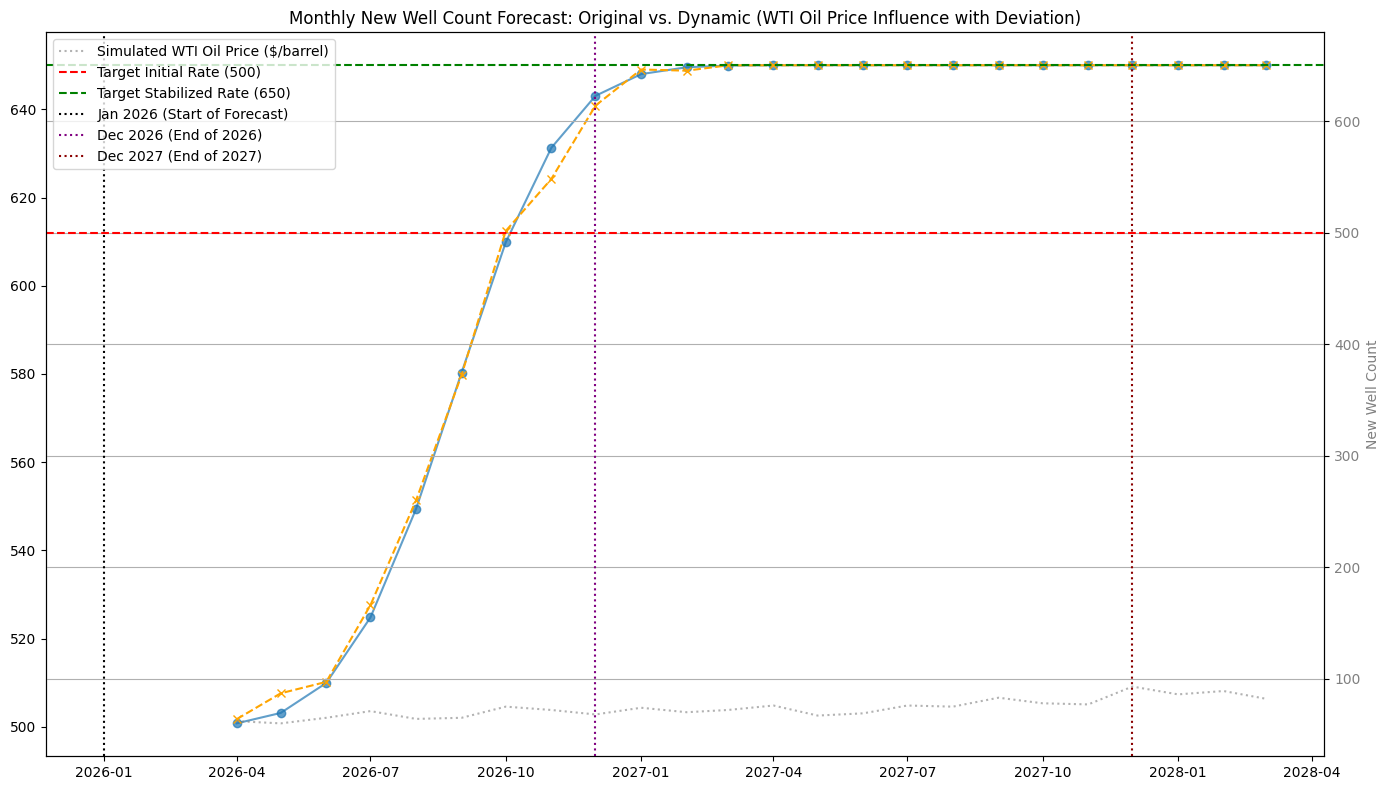


--- Dynamic Forecast Summary (WTI Oil Price Influenced with Deviation) ---
Initial month's rate (Month 0, dynamic): 501.71 wells/month
Total wells for first 12 months (dynamic): 7003.48 wells
Stabilized rate (Month 23, dynamic): 650.00 wells/month


In [31]:
import pandas as pd

# Re-calculate monthly well counts using dynamic sigma values derived from WTI oil price

# We'll keep t_mid constant for this example, but it could also be dynamic
# We iterate to apply a different sigma for each month's rate calculation.
# Note: This is a simplification; in a true dynamic system, the curve might be re-evaluated
# more frequently or with a different mathematical approach for month-to-month changes.

monthly_wells_oil_price_dynamic_forecast = []
for i, month_val in enumerate(months_forecast):
    # For each month, we use the corresponding dynamic sigma from oil price
    rate = s_curve_rate(month_val, optimized_t_mid, dynamic_sigmas_oil_price[i])
    monthly_wells_oil_price_dynamic_forecast.append(rate)

monthly_wells_oil_price_dynamic_forecast = np.array(monthly_wells_oil_price_dynamic_forecast)

# Define the start date for the forecast (NOW JANUARY 2026) and generate forecast_dates
start_date = pd.to_datetime('2026-01-01')
# Adjust forecast_dates to cover the new total_forecast_months (27 months from Jan 2026)
total_forecast_months = 27 # Explicitly set to 27 for consistency
forecast_dates = [start_date + pd.DateOffset(months=int(m)) for m in range(total_forecast_months)]

# Plotting the original forecast vs. dynamic forecast (Oil Price Influenced)
plt.figure(figsize=(14, 8))

# Original Forecast (24 months, starts April 2026 which is index 3 in forecast_dates)
plt.plot(forecast_dates[3:3+len(monthly_wells_forecast)], monthly_wells_forecast, marker='o', linestyle='-', label='Original S-curve Forecast', alpha=0.7)

# Dynamic Forecast (Oil Price Influenced) (24 months, starts April 2026 which is index 3 in forecast_dates)
plt.plot(forecast_dates[3:3+len(monthly_wells_oil_price_dynamic_forecast)], monthly_wells_oil_price_dynamic_forecast, marker='x', linestyle='--', color='orange', label='Dynamic S-curve Forecast (WTI Oil Price Influenced with Deviation)')

# Simulated WTI Oil Price (on a secondary axis) (24 months, starts April 2026)
ax2 = plt.gca().twinx()
ax2.plot(forecast_dates[3:3+len(wti_oil_price_simulated)], wti_oil_price_simulated, color='gray', linestyle=':', label='Simulated WTI Oil Price ($/barrel)', alpha=0.6)
ax2.set_ylabel('Simulated WTI Oil Price ($/barrel)', color='gray')
ax2.tick_params(axis='y', labelcolor='gray')

# Reference lines
plt.axhline(y=500, color='r', linestyle='--', label='Target Initial Rate (500)')
plt.axhline(y=650, color='g', linestyle='--', label='Target Stabilized Rate (650)')
plt.axvline(x=forecast_dates[0], color='k', linestyle=':', label='Jan 2026 (Start of Forecast)')
plt.axvline(x=forecast_dates[11], color='purple', linestyle=':', label='Dec 2026 (End of 2026)')
plt.axvline(x=forecast_dates[23], color='darkred', linestyle=':', label='Dec 2027 (End of 2027)')

plt.title('Monthly New Well Count Forecast: Original vs. Dynamic (WTI Oil Price Influence with Deviation)')
plt.xlabel('Date')
plt.ylabel('New Well Count')
plt.grid(True)
plt.legend(loc='upper left')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print(f"\n--- Dynamic Forecast Summary (WTI Oil Price Influenced with Deviation) ---")
print(f"Initial month's rate (Month 0, dynamic): {monthly_wells_oil_price_dynamic_forecast[0]:.2f} wells/month")
print(f"Total wells for first 12 months (dynamic): {np.sum(monthly_wells_oil_price_dynamic_forecast[:12]):.2f} wells")
print(f"Stabilized rate (Month 23, dynamic): {monthly_wells_oil_price_dynamic_forecast[-1]:.2f} wells/month")

This example shows how the `sigma` parameter, which controls the steepness of the S-curve, can be adjusted monthly based on an external factor like `WTI oil price`. To allow for scenarios where new wells might deviate from a perfect `oil price` response, a random deviation has been added to the `sigma` calculation. This introduces variability, simulating other unmeasured influences.

As the simulated `WTI oil price` increases, the `sigma` value generally decreases, making the S-curve steeper and accelerating the well count towards the stabilized rate. However, the added random component means the exact `sigma` for any given month will vary, leading to a less predictable but more realistic trajectory of new well counts.

To make this truly operational, you would need to:
1.  **Collect real `WTI oil price` data** for your specific oil region.
2.  **Develop a more robust statistical model** (e.g., regression analysis) to define the relationship between `WTI oil price` (and potentially other factors) and `t_mid` and `sigma` based on historical data.
3.  **Regularly update** the `WTI oil price` input to generate updated forecasts.
4.  **Calibrate the `deviation_strength`** parameter based on historical data to reflect the actual level of unpredictability.

### Scenario: Oil Price Collapse in August 2026

Let's model the scenario where oil prices collapse in August 2026. This will necessitate a shift from the previous growth-oriented S-curve to a new decline curve, eventually stabilizing at 530 wells per month.

We will implement this by:
1.  Identifying the new well count at the end of August 2026 from our current dynamic forecast. This will serve as the *starting point* for our decline.
2.  Designing a *new S-curve for decline* that transitions from this August 2026 rate down to the new stabilized rate of 530 wells/month.
3.  Combining the two forecasts: the existing dynamic forecast until August 2026, and the new decline S-curve thereafter.
4.  Plotting the combined scenario to visualize the impact.

In [32]:
# Identify the index for August 2026 (Month 7 of the new extended forecast, as Jan 2026 is Month 0)
# Jan=0, Feb=1, Mar=2, April=3, May=4, June=5, July=6, August=7
collapse_month_index = 7 # 7 Corresponds to August 2026

# Ensure total_forecast_months is 27 for consistency in this scenario
total_forecast_months = 27

# The new well count at the point of collapse (end of August 2026)
# `monthly_wells_oil_price_dynamic_forecast` starts from April 2026 (index 3 in the 27-month timeline).
# So, for August 2026 (index 7 in timeline), its index in `monthly_wells_oil_price_dynamic_forecast` is 7 - 3 = 4.
current_rate_at_collapse = monthly_wells_oil_price_dynamic_forecast[collapse_month_index - 3]

# New stabilized rate after the collapse
new_stabilized_rate = 530

print(f"Well count at end of August 2026 (collapse point): {current_rate_at_collapse:.2f} wells/month")
print(f"New target stabilized rate: {new_stabilized_rate} wells/month")

# We will use the same s_curve_rate function but with different initial/final rates and parameters
# to model the decline.

# Parameters for the decline S-curve:
# t_mid_decline: Midpoint of the decline. Let's assume it takes a few months to reach the steepest decline.
#                Relative to the start of the decline phase (collapse_month_index).
# sigma_decline: Steepness of the decline. Smaller sigma -> faster decline.

# Initial guess for decline parameters (these might need adjustment for desired visual effect)
# Let's try to have the steepest decline around 3 months after collapse, and a sigma of 2
t_mid_decline = 3 # months after collapse
sigma_decline = 2 # controls steepness of decline

# Create the combined forecast array - it should now be `total_forecast_months` long
combined_forecast = np.zeros(total_forecast_months)

# Part 1: Pad Jan-Mar 2026 with a placeholder (e.g., 500, or a value that will be overridden)
# The `monthly_wells_oil_price_dynamic_forecast` still starts at April 2026.
combined_forecast[0:3] = 500 # Fixed for Jan, Feb, Mar

# Part 2: Use the oil-price-driven dynamic forecast from April 2026 up to the collapse point
# The collapse is in August 2026, which is index 7 in the new `forecast_dates`
# April 2026 is index 3 in the new `forecast_dates`.
# The `monthly_wells_oil_price_dynamic_forecast` has index 0 for April 2026.
# So we copy `monthly_wells_oil_price_dynamic_forecast` (up to its index 4, which is Aug 2026)
# into `combined_forecast` from index 3 up to index 7.
# The length of monthly_wells_oil_price_dynamic_forecast needed here is (collapse_month_index - 3) + 1 = 5 elements (indices 0-4)
combined_forecast[3 : collapse_month_index + 1] = monthly_wells_oil_price_dynamic_forecast[: (collapse_month_index - 3) + 1]

# Part 3: Model the decline from the collapse point onwards
# The decline starts at `collapse_month_index` (Aug 2026) in the `combined_forecast`.
# The initial rate for the decline curve is `current_rate_at_collapse`.
months_after_collapse_new_timeline = np.arange(total_forecast_months - collapse_month_index)
decline_rates = s_curve_rate(months_after_collapse_new_timeline, t_mid_decline, sigma_decline,
                             initial_rate=current_rate_at_collapse, final_rate=new_stabilized_rate)

combined_forecast[collapse_month_index:] = decline_rates

print(f"\nCombined Forecast (first 5 months, new timeline):")
for i in range(min(5, total_forecast_months)): # Use total_forecast_months here
    print(f"Month {i} ({forecast_dates[i].strftime('%Y-%m')}): {combined_forecast[i]:.2f} wells/month")
print(f"...")
print(f"Rate at Month {collapse_month_index} ({forecast_dates[collapse_month_index].strftime('%Y-%m')}): {combined_forecast[collapse_month_index]:.2f} wells/month (Collapse Point)")
print(f"Rate at Month {collapse_month_index+1} ({forecast_dates[collapse_month_index+1].strftime('%Y-%m')}): {combined_forecast[collapse_month_index+1]:.2f} wells/month (Start of Decline)")
print(f"Last month's rate ({forecast_dates[-1].strftime('%Y-%m')}): {combined_forecast[-1]:.2f} wells/month (New Stabilization)")

Well count at end of August 2026 (collapse point): 551.32 wells/month
New target stabilized rate: 530 wells/month

Combined Forecast (first 5 months, new timeline):
Month 0 (2026-01): 500.00 wells/month
Month 1 (2026-02): 500.00 wells/month
Month 2 (2026-03): 500.00 wells/month
Month 3 (2026-04): 501.71 wells/month
Month 4 (2026-05): 507.59 wells/month
...
Rate at Month 7 (2026-08): 549.90 wells/month (Collapse Point)
Rate at Month 8 (2026-09): 547.94 wells/month (Start of Decline)
Last month's rate (2028-03): 530.00 wells/month (New Stabilization)


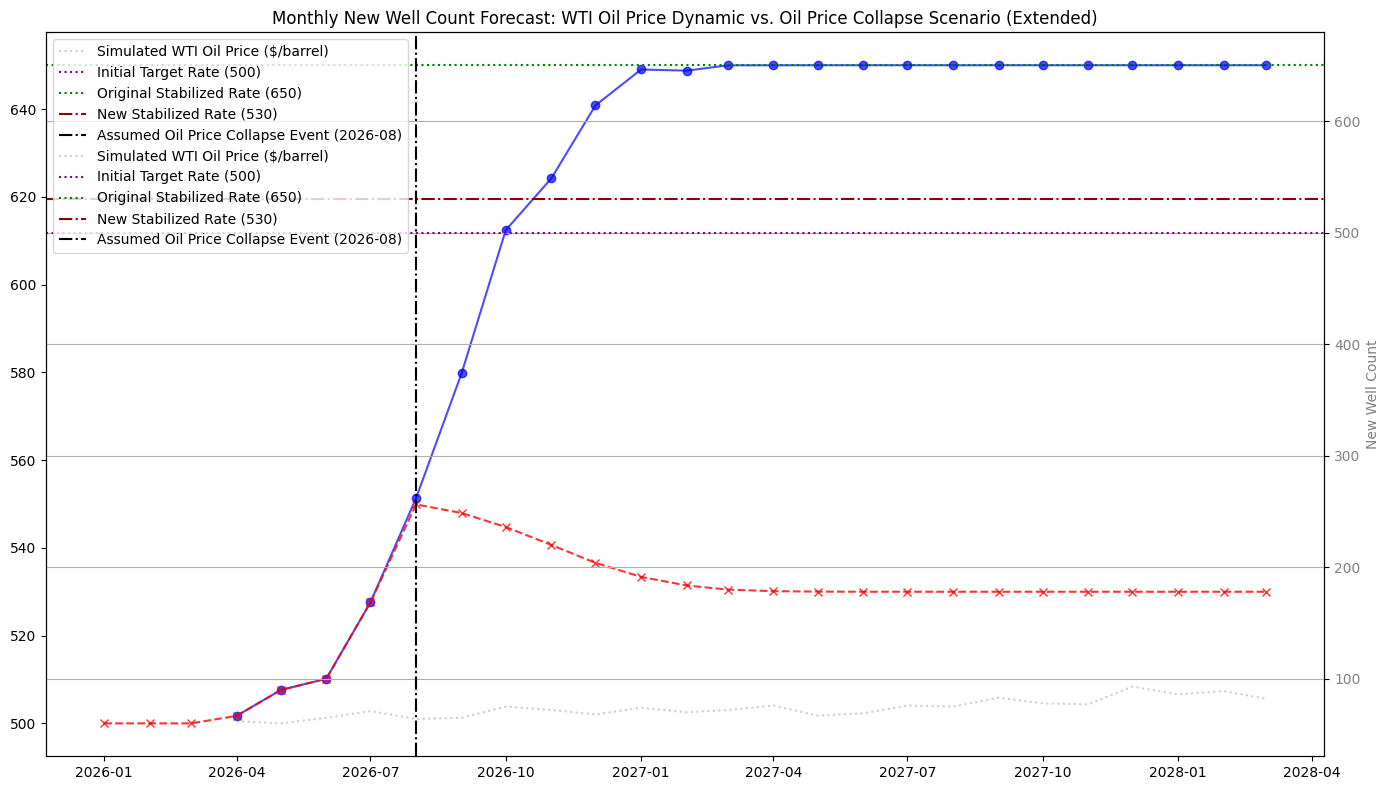

In [33]:
import pandas as pd # Ensure pandas is imported for pd.to_datetime and DateOffset

# Define the start date for the forecast (NOW JANUARY 2026) and generate forecast_dates
# Explicitly recreate forecast_dates here to ensure correct length for plotting
start_date = pd.to_datetime('2026-01-01')
total_forecast_months_for_plot = 27 # Use 27 months for the full timeline
forecast_dates = [start_date + pd.DateOffset(months=int(m)) for m in range(total_forecast_months_for_plot)]

# Plotting the new scenario alongside the oil-price-driven dynamic forecast
plt.figure(figsize=(14, 8))

# Oil Price Driven Dynamic Forecast (for comparison) - This was 24 months, starting April 2026
# We plot it from its actual start date in the new extended forecast_dates.
plt.plot(forecast_dates[3:3+len(monthly_wells_oil_price_dynamic_forecast)], monthly_wells_oil_price_dynamic_forecast, marker='o', linestyle='-', color='blue', label='Dynamic Forecast (WTI Oil Price Influence)', alpha=0.7)

# New Scenario with Price Collapse (now `total_forecast_months` long, starting Jan 2026)
plt.plot(forecast_dates, combined_forecast, marker='x', linestyle='--', color='red', label='Scenario: Oil Price Collapse (Extended Timeline)', alpha=0.8)

# Simulated WTI Oil Price (on a secondary axis - just for context of original model)
ax2 = plt.gca().twinx()
# WTI Oil Price was simulated for 24 months, starting April 2026
ax2.plot(forecast_dates[3:3+len(wti_oil_price_simulated)], wti_oil_price_simulated, color='gray', linestyle=':', label='Simulated WTI Oil Price ($/barrel)', alpha=0.4)
ax2.set_ylabel('Simulated WTI Oil Price ($/barrel)', color='gray')
ax2.tick_params(axis='y', labelcolor='gray')

# Reference lines
plt.axhline(y=500, color='purple', linestyle=':', label='Initial Target Rate (500)')
plt.axhline(y=650, color='green', linestyle=':', label='Original Stabilized Rate (650)')
plt.axhline(y=new_stabilized_rate, color='darkred', linestyle='-.', label=f'New Stabilized Rate ({new_stabilized_rate})')

# Mark the collapse point (now at index 7 for August 2026)
plt.axvline(x=forecast_dates[collapse_month_index], color='black', linestyle='-.',
            label=f'Assumed Oil Price Collapse Event ({forecast_dates[collapse_month_index].strftime('%Y-%m')})')

plt.title('Monthly New Well Count Forecast: WTI Oil Price Dynamic vs. Oil Price Collapse Scenario (Extended)')
plt.xlabel('Date')
plt.ylabel('New Well Count')
plt.grid(True)
# Combine legends from both axes
lines, labels = plt.gca().get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines + lines2, labels + labels2, loc='upper left')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

This new plot clearly illustrates the impact of the simulated oil price collapse. The forecast follows the initial dynamic S-curve until August 2026, after which it transitions into a new decline phase, gradually reaching the new stabilized rate of 530 wells per month. The red dashed line represents this new scenario, showing a clear deviation from the blue line (original dynamic forecast) after the collapse.

To refine this decline model further, you might consider:
*   **Optimizing the decline S-curve parameters (`t_mid_decline`, `sigma_decline`)**: If you have historical data on how well counts respond to price collapses (e.g., how quickly they decline and stabilize), these parameters could be optimized similar to how the initial S-curve was optimized.
*   **Step-wise decline**: Instead of a smooth S-curve, a more abrupt, step-wise decline followed by a different stabilization pattern might be more realistic depending on the nature of the price collapse and operational responses.
*   **Dynamic `initial_rate` for decline**: Instead of taking `monthly_wells_dynamic_forecast[collapse_month_index]` directly, you might have a specific immediate reaction (e.g., a certain percentage drop) at the point of collapse, before the gradual decline sets in.